# Induced-EQ Forecasting Analysis

Modified from *Using Deep Learning for Flexible and Scalable Earthquake Forecasting*.
Reference: [Zenodo](https://zenodo.org/records/8161777)

## 1) Setup

In [2]:
import os
import sys
import functools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import json


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError("Cannot find project root containing 'src' directory.")


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import src
import src.catalogs as catalogs
import src.utils.catalog_tests as catalog_tests
from src.models.tpp import etas, etas_zhuang, recurrent
from src.train.config_setup import load_and_prepare_model
from src.utils.forecast_eval import (
    apply_publication_style,
    evaluate_sliding_window_forecast_plots,
    save_pub_figure,
    style_current_figure,
    )
from src.utils.tpp_experiments import load_tpp_catalog, sample_tpp_forecasts
from src.utils.utils import set_seed
from src.utils.viz_sequences import visualize_sequence, visualize_trajectories, plot_intensity

apply_publication_style()

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
set_seed(0)
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DEVICE: {DEVICE}')

PROJECT_ROOT: /root/autodl-tmp/em_eqf
DEVICE: cuda:0


## 2) Configuration

In [3]:
CHECKPOINT_DIR = PROJECT_ROOT / 'checkpoints/etas_20260610-223302'
CHECKPOINT_PATH = CHECKPOINT_DIR / 'best_model_1.pth'

# Optional: replace current background model with another checkpoint's background model.
USE_ALT_BG_MODEL = False
ALT_BG_CHECKPOINT_PATH = PROJECT_ROOT / 'checkpoints' / 'etas_20251221-224107' / 'best_model_1.pth'

USE_TORCH_COMPILE = False
MODEL_MM = 4  # set to None to skip overriding model.M_m

print(f'CHECKPOINT_PATH: {CHECKPOINT_PATH}')

CHECKPOINT_PATH: /root/autodl-tmp/em_eqf/checkpoints/etas_20260610-223302/best_model_1.pth


## 3) Load Model and Catalog

In [4]:
from src.utils.runtime_utils import unwrap_compiled_model

model, args = load_and_prepare_model(
    checkpoint_path=CHECKPOINT_PATH,
    device=DEVICE,
    compile=USE_TORCH_COMPILE,
)
model = unwrap_compiled_model(model)

if USE_ALT_BG_MODEL:
    alt_model, _ = load_and_prepare_model(
        checkpoint_path=ALT_BG_CHECKPOINT_PATH,
        device=DEVICE,
        compile=False,
    )
    alt_model = unwrap_compiled_model(alt_model)
    if getattr(alt_model, 'bg_model', None) is not None:
        model.bg_model = alt_model.bg_model
    del alt_model

if MODEL_MM is not None and hasattr(model, 'M_m'):
    model.M_m = torch.tensor(float(MODEL_MM), device=DEVICE)

if getattr(model, 'bg_model', None) is not None:
    print(f'background scale: {model.bg_model._scale}')

if hasattr(model, 'print_params'):
    model.print_params()
if hasattr(model, 'effective_branching_ratio'):
    print(f"Effective branching ratio: {model.effective_branching_ratio():.4f}")

background scale: 314.696533203125
ETAS model parameters:
  p = 1.8599170446395874
  c = 0.005493085831403732
  mu = 0.0
  k = 0.0046755168586969376
  K = 0.4774671494960785
  alpha = 0.3771788775920868
  alpha_e = 0.8684864640235901
  b = 0.8843895196914673
  M_c = -0.4000000059604645
  M_m = 4.0
Effective branching ratio: 0.8277


Using catalog registry name: CB_HAB1a-Standard


<Axes: xlabel='Arrival time (days)', ylabel='Magnitude'>

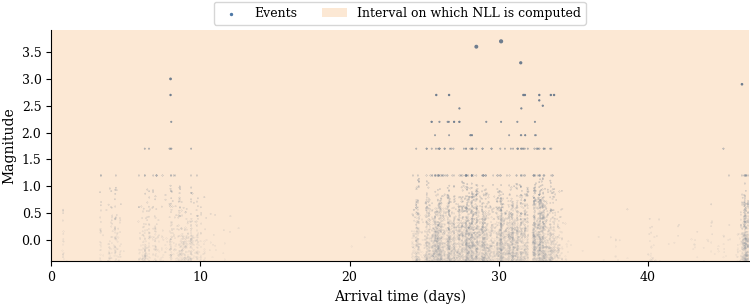

In [5]:
catalog_cfg = getattr(args, 'catalog_cfg', {})
catalog_ds, registry_name, catalog_init_kwargs = load_tpp_catalog(
    args.dataset,
    base_dir=PROJECT_ROOT / 'data' / args.dataset,
    catalog_cfg=catalog_cfg,
)
print(f'Using catalog registry name: {registry_name}')

metadata = catalog_ds.metadata
if  hasattr(metadata, 'start_ts') and hasattr(metadata, 'val_start_ts') and hasattr(metadata, 'test_start_ts') and hasattr(metadata, 'freq'):
    start_ts = pd.to_datetime(metadata['start_ts'])
    val_start_ts = pd.to_datetime(metadata['val_start_ts'])
    test_start_ts = pd.to_datetime(metadata['test_start_ts'])
    freq_td = pd.to_timedelta(metadata['freq'])

    print(f'Model: {args.model} | Dataset: {args.dataset}')
    print(f'train end index: {(val_start_ts - start_ts) / freq_td}')
    print(f'val end index: {(test_start_ts - start_ts) / freq_td}')

full_seq = catalog_ds.full_sequence
sequences = catalog_ds.sequences if hasattr(catalog_ds, 'sequences') else [full_seq]

visualize_sequence(full_seq, show_nll=True)

In [6]:
if hasattr(model, 'effective_branching_ratio'):
   print(f'branching ratio: {model.effective_branching_ratio()}')

branching ratio: 0.8277477976048709


In [7]:
model.bg_model.stochastic_eval = False

In [8]:
catalog_ds.metadata

{'name': 'CB_HAB1a',
 'freq': '1D',
 'freq_min': 1,
 'source_freq_min': 1,
 'inj_source_freq_min': 1,
 'inj_resampled': False,
 'mag_roundoff_error': 0.01,
 'mag_completeness': -0.4,
 'normalize_time_series': True,
 'start_ts': Timestamp('2003-11-06 00:01:09.999000'),
 'end_ts': Timestamp('2003-12-22 17:59:09.999000'),
 'train_start_ts': Timestamp('2003-11-06 00:01:09.999000'),
 'val_start_ts': Timestamp('2003-12-08 17:23:45.999000'),
 'test_start_ts': Timestamp('2003-12-15 17:41:27.999000'),
 'start_t': 0.0,
 'end_t': 46.74861111111111,
 'train_start_t': 0.0,
 'val_start_t': 32.72402777777778,
 'test_start_t': 39.73631944444445,
 'inj_fill_policy': 'upsample_ffill',
 'is_upsample': True}

In [9]:
ts_start = catalog_ds.metadata["start_ts"]
mc = catalog_ds.metadata["mag_completeness"]
CKPT_PREDICT_B = bool(getattr(args, "predict_b", False))

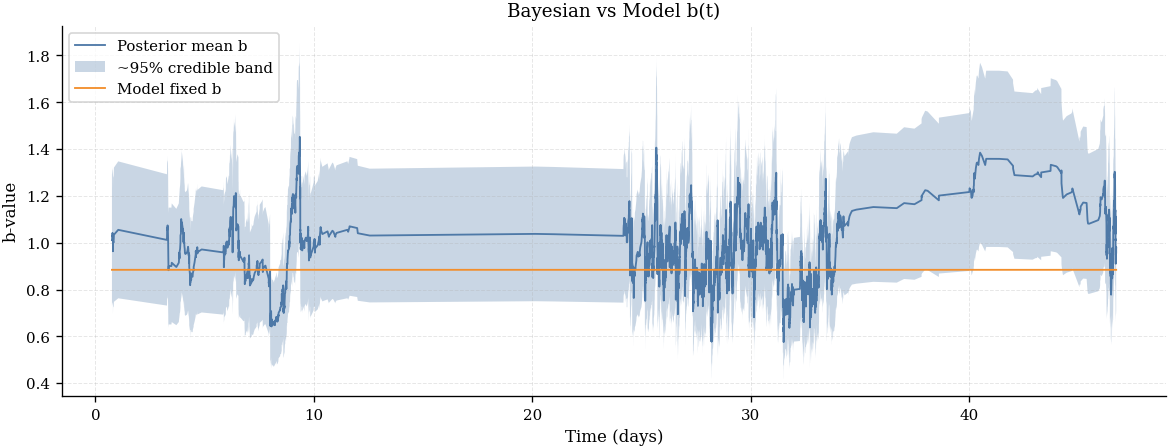

In [10]:
from src.models.updaters import BayesianGRBUpdater
from src.utils.b_value_plot import plot_b_value


def _model_b_series_for_plot(model, seq, *, predict_b=None):
    """Return model b(t) on event axis for plotting, or None if unavailable."""
    n_events = int(len(getattr(seq, "mag", [])))
    if n_events <= 0:
        return None

    predict_b_flag = bool(getattr(model, "predict_b", False)) if predict_b is None else bool(predict_b)

    if hasattr(model, "compute_b_value"):
        try:
            b_series = torch.as_tensor(model.compute_b_value(seq, predict_b=predict_b_flag)).detach().cpu()
            if b_series.ndim == 1:
                b_series = b_series.unsqueeze(0)
            if b_series.shape[1] == n_events + 1:
                b_series = b_series[:, :-1]
            elif b_series.shape[1] != n_events:
                b_series = b_series[:, :n_events]
            return b_series
        except Exception as exc:
            print(f"compute_b_value failed, fallback to scalar b: {exc}")

    for attr_name in ("richter_b", "b"):
        if hasattr(model, attr_name):
            b_raw = getattr(model, attr_name)
            b_scalar = float(b_raw.detach().cpu().item() if torch.is_tensor(b_raw) else b_raw)
            return torch.full((1, n_events), b_scalar, dtype=torch.float32)

    return None


bayes_updater = BayesianGRBUpdater(
    Mc=mc,
    delta=0.98,
    a0=50,
    init_b_target=1,
    mag_key="mag",
    write_back=True,
)
_ = bayes_updater.fit(full_seq, prefix="bayes_")
b_pred = _model_b_series_for_plot(model, full_seq, predict_b=CKPT_PREDICT_B)

fig, ax = plt.subplots(figsize=(10, 4))
BayesianGRBUpdater.plot(
    full_seq,
    x_axis="time",
    time_key="arrival_times",
    prefix="bayes_",
    ax=ax,
    title="",
    show=False,
    start_time=None,
)

if b_pred is not None and b_pred.numel() > 0:
    model_label = "Model prediction" if CKPT_PREDICT_B else "Model fixed b"
    plot_b_value(
        full_seq,
        b_pred,
        label=model_label,
        smooth=False,
        fig=fig,
        ax=ax,
        show=False,
        start_time=None,
    )
else:
    print("Skip model b(t) overlay: model has no b-value interface.")

ax.set_title("Bayesian vs Model b(t)")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

## 4) Batch and Intensity Diagnostics

In [ ]:
def sequence_to_batch(seq, device):
    batch = src.data.Batch.from_list([seq])
    return batch.to(device)

SEQUENCE_IDX = 0
seq = sequences[SEQUENCE_IDX]
batch = sequence_to_batch(seq, DEVICE)

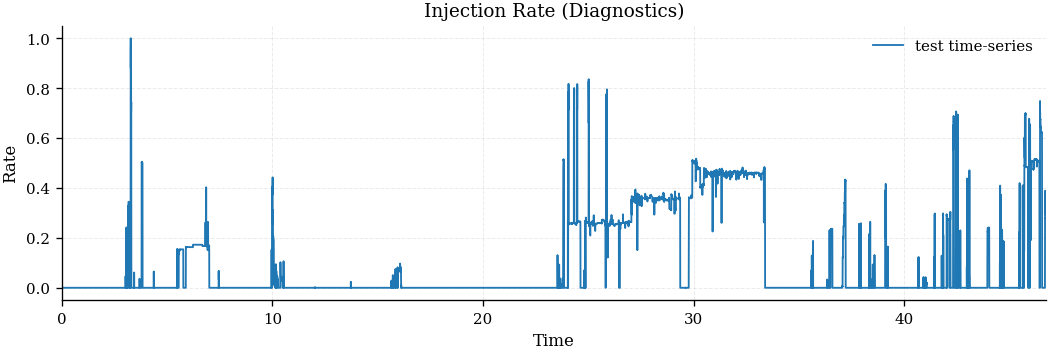

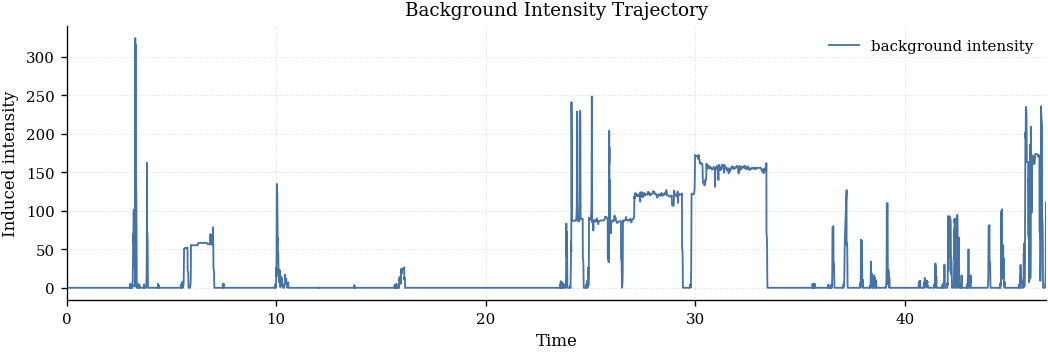

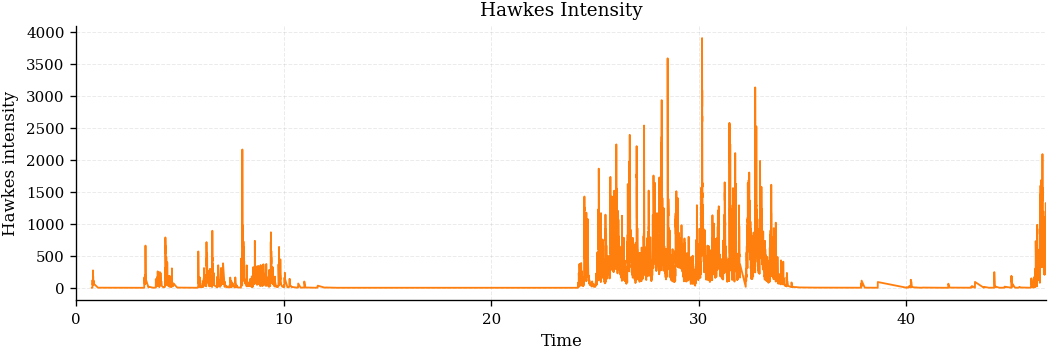

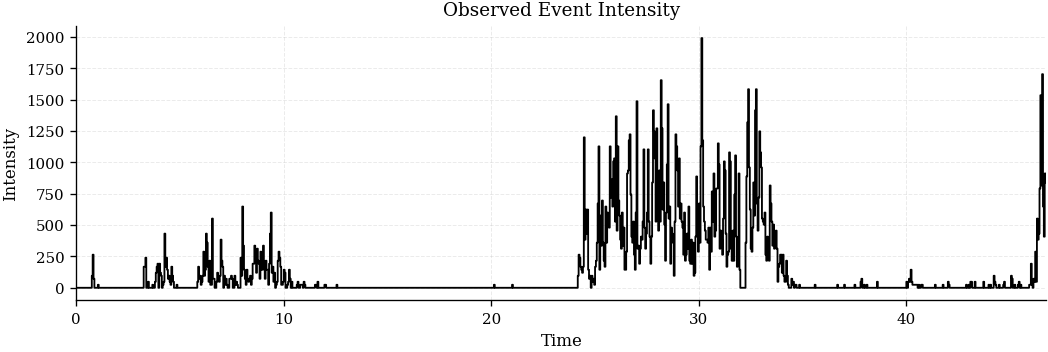

In [ ]:
diag_times = batch.time_series_times.reshape(-1)
if diag_times.numel() > 0:
    diag_start = float(diag_times.min().item())
    diag_end = float(diag_times.max().item())
else:
    diag_start = float(seq.t_start)
    diag_end = float(seq.t_end)

diag_colors = {
    'series': '#1f77b4',
    'bg': "#4573a5",
    'hist': '#d62728',
    'hawkes': '#ff7f0e',
}

def _apply_diag_axis(ax, xlabel='Time', ylabel=None, title=None):
    ax.set_xlim(diag_start, diag_end)
    ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    if title is not None:
        ax.set_title(title)
    ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(
    batch.time_series_times.squeeze().detach().cpu().numpy(),
    batch.time_series.squeeze().detach().cpu().numpy(),
    linewidth=1.1,
    color=diag_colors['series'],
    label='test time-series',
)
_apply_diag_axis(ax, ylabel='Rate', title='Injection Rate (Diagnostics)')
ax.legend(frameon=False)
fig.tight_layout()
save_pub_figure(fig, CHECKPOINT_DIR / 'diagnostic_injection_rate.png')
plt.show()

if getattr(model, 'bg_model', None) is not None:
    f_intensity_trajectory = model.bg_model.intensity_trajectory(batch)
    fig, ax = plt.subplots(figsize=(9, 3.2))
    ax.plot(
        batch.time_series_times.squeeze().detach().cpu().numpy(),
        f_intensity_trajectory.squeeze().detach().cpu().numpy(),
        linewidth=1.1,
        color=diag_colors['bg'],
        label='background intensity',
    )
    _apply_diag_axis(ax, ylabel='Induced intensity', title='Background Intensity Trajectory')
    ax.legend(frameon=False)
    fig.tight_layout()
    save_pub_figure(fig, CHECKPOINT_DIR / 'induced_intensity.png')
    plt.show()

if isinstance(model, recurrent.RecurrentTPP):
    context = model.get_context(batch)
    inter_time_dist = model.get_inter_time_dist(context)
    log_h = inter_time_dist.log_hazard(batch.inter_times.clamp_min(1e-10))
    h_intensity = torch.exp(log_h)
    h_intensity = torch.where(h_intensity > 500000, torch.tensor(0.0, device=h_intensity.device), h_intensity)

    window = 20
    arrival_times_np = batch.arrival_times.detach().cpu().numpy().ravel()
    raw_np = h_intensity.detach().cpu().numpy().ravel()
    smoothed = np.convolve(raw_np, np.ones(window) / window, mode='same')

    fig, ax = plt.subplots(figsize=(9, 3.2))
    ax.plot(
        arrival_times_np,
        smoothed,
        linewidth=1.1,
        color=diag_colors['hist'],
        label='smoothed history intensity',
    )
    _apply_diag_axis(ax, ylabel='History intensity', title='History-Triggered Intensity (Smoothed)')
    ax.legend(frameon=False)
    fig.tight_layout()
    save_pub_figure(fig, CHECKPOINT_DIR / 'history_intensity_smoothed.png')
    plt.show()

    print('count(h_intensity > 1000):', int((h_intensity > 1000).sum().item()))
elif isinstance(model, (etas.ETAS, etas_zhuang.ETASZhuang)):
    h_intensity = model.h_intensity(batch)
    fig, ax = plt.subplots(figsize=(9, 3.2))
    ax.plot(
        batch.arrival_times.reshape(-1)[:-1].detach().cpu().numpy(),
        h_intensity.reshape(-1).detach().cpu().numpy(),
        linewidth=1.1,
        color=diag_colors['hawkes'],
    )
    _apply_diag_axis(ax, ylabel='Hawkes intensity', title='Hawkes Intensity')
    fig.tight_layout()
    save_pub_figure(fig, CHECKPOINT_DIR / 'hawkes_intensity.png')
    plt.show()

fig, ax = plt.subplots(figsize=(9, 3.2))
plot_intensity(seq, dt=1/24, ax=ax, T0=diag_start, T=diag_end)
_apply_diag_axis(ax, ylabel='Intensity', title='Observed Event Intensity')
fig.tight_layout()
save_pub_figure(fig, CHECKPOINT_DIR / 'observed_event_intensity.png')
plt.show()


## 5) Single-Window Forecast

In [ ]:
# Single forecast window settings
T_FORECAST = 30
FORECAST_DURATION = 3
NUM_SAMPLES = 1000
SAMPLES_PER_BATCH = min(NUM_SAMPLES, 1000)

# b(t) sampling mode during sampling:
# - 'model': use model's magnitude head
# - 'updater': use updater posterior mean b


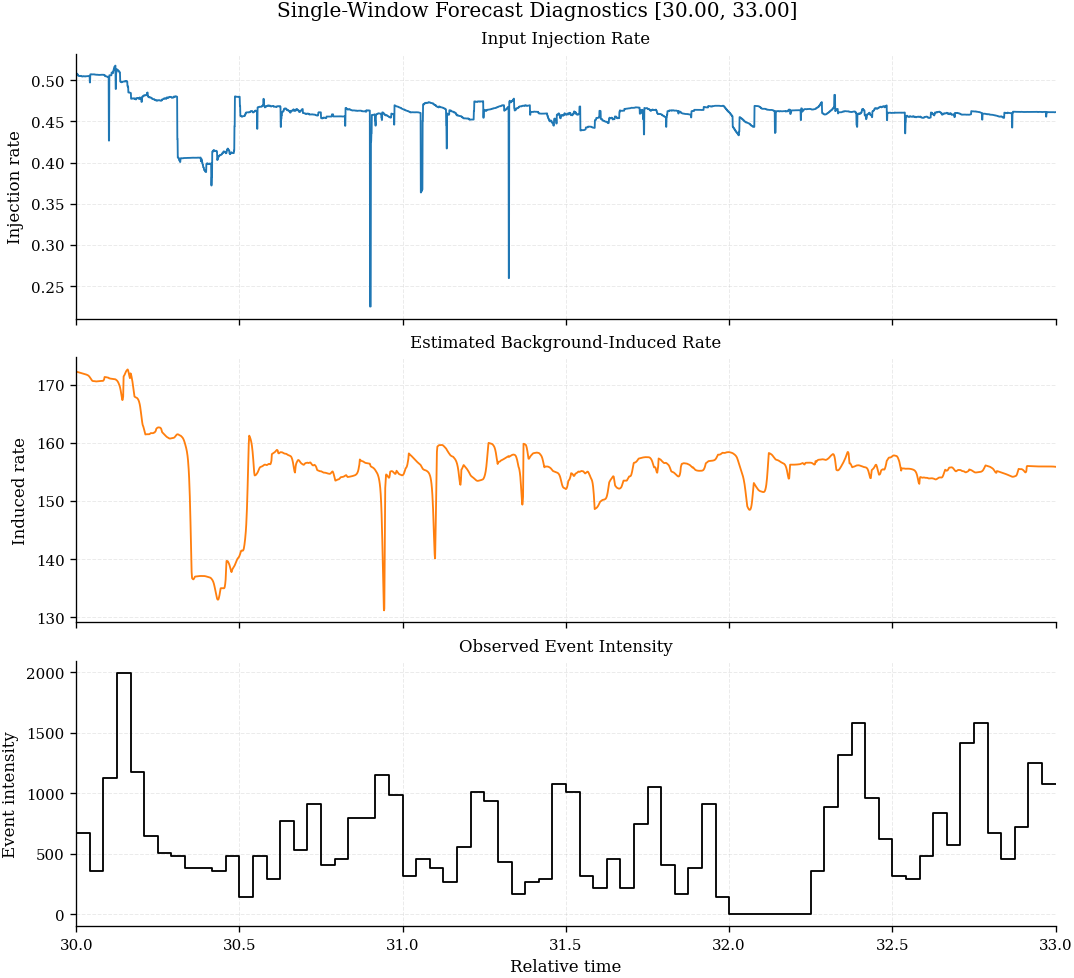

Background forecast count in [30, 33]: 467.37701416015625
Observed events in window: 1827


In [ ]:
past_seq = seq.get_subsequence(0, T_FORECAST, reset_t_nll_to_end=True)
observed_seq = seq.get_subsequence(T_FORECAST, T_FORECAST + FORECAST_DURATION, reset_t_nll_to_end=True)

window_start = float(T_FORECAST)
window_end = float(T_FORECAST + FORECAST_DURATION)

mask_future = (seq.time_series_times >= window_start) & (seq.time_series_times < window_end)
future_time_series = seq.time_series[mask_future]
future_time_series_times = seq.time_series_times[mask_future]

window_colors = {
    'inj': '#1f77b4',
    'bg': '#ff7f0e',
    'obs': '#2ca02c',
}

def _apply_window_axis(ax, ylabel=None, title=None, show_xlabel=False):
    ax.set_xlim(window_start, window_end)
    if show_xlabel:
        ax.set_xlabel('Relative time')
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    if title is not None:
        ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

if getattr(model, 'bg_model', None) is not None:
    model.bg_model.cache_batch(
        time_series=seq.time_series.unsqueeze(0),
        time_series_times=seq.time_series_times.unsqueeze(0),
    )
    times_all = seq.time_series_times
    window_mask = (times_all >= window_start) & (times_all < window_end)
    window_times = times_all[window_mask]
    f_intensity = model.bg_model.intensity(
        ts_batch=model.bg_model.ts_batch_cache,
        t_query=window_times.unsqueeze(0),
    )

    fig, (ax_inj, ax_bg, ax_obs) = plt.subplots(
        3, 1, figsize=(9, 8.2), sharex=True, constrained_layout=True
    )
    fig.suptitle(f'Single-Window Forecast Diagnostics [{window_start:.2f}, {window_end:.2f}]', fontsize=12)

    ax_inj.plot(
        future_time_series_times.detach().cpu().numpy(),
        future_time_series.reshape(-1).detach().cpu().numpy(),
        linewidth=1.1,
        color=window_colors['inj'],
    )
    _apply_window_axis(
        ax_inj,
        ylabel='Injection rate',
        title='Input Injection Rate',
    )

    ax_bg.plot(
        window_times.detach().cpu().numpy(),
        f_intensity.reshape(-1).detach().cpu().numpy(),
        linewidth=1.1,
        color=window_colors['bg'],
    )
    _apply_window_axis(
        ax_bg,
        ylabel='Induced rate',
        title='Estimated Background-Induced Rate',
    )

    plot_intensity(
        observed_seq,
        dt=1 / 24,
        ax=ax_obs,
        T0=window_start,
        T=window_end,
    )
    _apply_window_axis(
        ax_obs,
        ylabel='Event intensity',
        title='Observed Event Intensity',
        show_xlabel=True,
    )

    save_pub_figure(fig, CHECKPOINT_DIR / 'single_window_forecast_diagnostics.png')
    plt.show()

    bg_count = model.bg_model.forecast_count(window_start, window_end)
    print(f'Background forecast count in [{window_start:g}, {window_end:g}]: {bg_count}')
else:
    fig, (ax_inj, ax_obs) = plt.subplots(
        2, 1, figsize=(9, 5.8), sharex=True, constrained_layout=True
    )
    fig.suptitle(f'Single-Window Forecast Diagnostics [{window_start:.2f}, {window_end:.2f}]', fontsize=12)

    ax_inj.plot(
        future_time_series_times.detach().cpu().numpy(),
        future_time_series.reshape(-1).detach().cpu().numpy(),
        linewidth=1.1,
        color=window_colors['inj'],
    )
    _apply_window_axis(
        ax_inj,
        ylabel='Injection rate',
        title='Input Injection Rate',
    )

    plot_intensity(
        observed_seq,
        dt=1 / 24,
        ax=ax_obs,
        T0=window_start,
        T=window_end,
    )
    _apply_window_axis(
        ax_obs,
        ylabel='Event intensity',
        title='Observed Event Intensity',
        show_xlabel=True,
    )

    save_pub_figure(fig, CHECKPOINT_DIR / 'single_window_forecast_diagnostics.png')
    plt.show()

print('Observed events in window:', len(observed_seq))


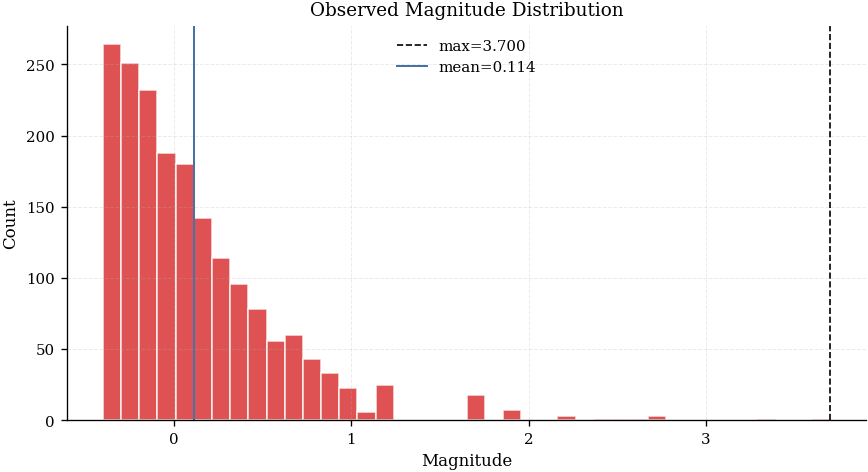

In [ ]:
obs_mag = observed_seq.mag.detach().cpu().numpy().reshape(-1)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.hist(obs_mag, bins=40, color=diag_colors['hist'], alpha=0.8, edgecolor='white')
ax.axvline(obs_mag.max(), color='black', linestyle='--', linewidth=1.0, label=f"max={obs_mag.max():.3f}")
ax.axvline(obs_mag.mean(), color=diag_colors['bg'], linestyle='-', linewidth=1.2, label=f"mean={obs_mag.mean():.3f}")

ax.set_title('Observed Magnitude Distribution')
ax.set_xlabel('Magnitude')
ax.set_ylabel('Count')
ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False)

fig.tight_layout()
plt.show()

In [ ]:
import inspect

FORECAST_B_SAMPLING = 'model'  # options: 'model', 'updater'
UPDATER_NAME = 'bayesian_gr'  # options: 'bayesian_gr', 'pyro_kf'
UPDATER_CFG = {
    'delta': 0.98,
    'a0': 50,
    'init_b_target': 1,
}
# UPDATER_CFG = {
#       "prior_b_mean": 1.0,
#       "num_particles": 128,
#       "ess_threshold": 0.6,
#       "min_dt": 1e-6,
#       "rng_seed": 3,
#       "device": torch.device("cuda:0" if torch.cuda.is_available() else "cpu"),
#       "dtype": torch.float32,
#   }


def _supports_dynamic_b_sampling(m):
    """True for RTPP-like models that support sampler-side b modes/updaters."""
    try:
        params = inspect.signature(m.sample).parameters
        if any(k in params for k in ('b_sampling', 'updater', 'updater_name', 'updater_cfg')):
            return True
    except Exception:
        pass
    return hasattr(m, "_normalize_b_sampling_mode")


model_name = str(getattr(args, "model", "")).lower()
IS_ETAS_FAMILY = model_name in {"etas", "etas_zhuang"} or isinstance(model, (etas.ETAS, etas_zhuang.ETASZhuang))
SUPPORTS_DYNAMIC_B_SAMPLING = _supports_dynamic_b_sampling(model)

if FORECAST_B_SAMPLING == 'updater' and not SUPPORTS_DYNAMIC_B_SAMPLING:
    print(
        f"Current model ({model_name or type(model).__name__}) does not support updater-based b sampling; "
        "force FORECAST_B_SAMPLING='model'."
    )
    FORECAST_B_SAMPLING = 'model'

if hasattr(model, "predict_b"):
    model.predict_b = CKPT_PREDICT_B

print(f"Checkpoint predict_b: {CKPT_PREDICT_B}")
print(f"Forecast b sampling: {FORECAST_B_SAMPLING}")
print(f"Forecast updater: {UPDATER_NAME}")
print(f"Dynamic b sampling supported: {SUPPORTS_DYNAMIC_B_SAMPLING}")
print(f"ETAS-family model: {IS_ETAS_FAMILY}")


Checkpoint predict_b: False
Forecast b sampling: model
Forecast updater: bayesian_gr
Dynamic b sampling supported: False
ETAS-family model: True


In [ ]:
# simplified updater sampling cell
def _infer_model_dtype(model):
    try:
        return next(model.parameters()).dtype
    except Exception:
        return torch.get_default_dtype()


def make_sampling_updater():
    cfg = dict(UPDATER_CFG or {})
    return build_sampling_updater(
        model=model,
        mc=float(mc),
        updater_name=UPDATER_NAME,
        updater_cfg=cfg,
        device=getattr(model, "device", DEVICE),
    )


from src.models.updaters import UpdaterSamplingWrapper, build_sampling_updater


if FORECAST_B_SAMPLING == 'updater':
    sampling_model = UpdaterSamplingWrapper(
        model,
        sampling_mode=FORECAST_B_SAMPLING,
        updater_factory=make_sampling_updater,
    )
else:
    sampling_model = model

past_seq_device = past_seq.to(DEVICE) if torch.cuda.is_available() else past_seq
all_forecasts = sample_tpp_forecasts(
    model=sampling_model,
    past_seq=past_seq_device,
    duration=FORECAST_DURATION,
    num_samples=NUM_SAMPLES,
    samples_per_batch=SAMPLES_PER_BATCH,
    bg_cache_seq=seq,
    seed=3,
    predict_b=CKPT_PREDICT_B,
)

zero_indices = []
for idx, fc in enumerate(all_forecasts):
    inter_times = torch.as_tensor(fc.inter_times).cpu()
    if (inter_times == 0).any():
        zero_indices.append(idx)

print('Total forecasts:', len(all_forecasts))
print('Forecasts containing zero inter_times:', len(zero_indices))
date_strs = catalog_ds.metadata['start_ts'].strftime('%Y-%m-%d') if hasattr(catalog_ds.metadata['start_ts'], 'strftime') else 'start'
visualize_trajectories(
    seq,
    all_forecasts,
    save_path=CHECKPOINT_DIR / 'all_forecasts.pdf',
    figsize=(10, 3),
    xlabel='Days since ' + date_strs,
    reset_t_nll_to_end=True,
)


  0%|          | 0/1000 [00:00<?, ?it/s]

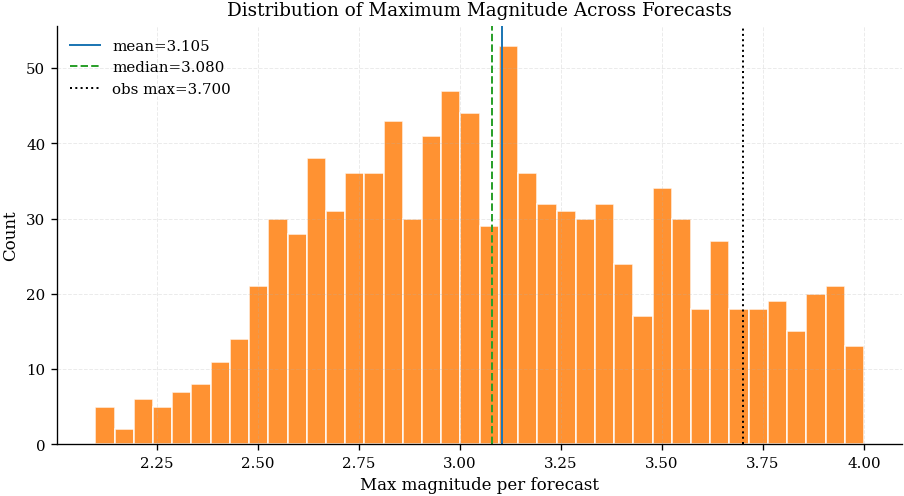

Used forecasts: 1000 / 1000
MAE of max magnitude: 0.627


In [ ]:
max_mags = [torch.as_tensor(fc.mag).max().item() for fc in all_forecasts if len(fc) > 0]
max_mags = np.asarray(max_mags, dtype=float)

fig, ax = plt.subplots(figsize=(7.8, 4.4))
ax.hist(max_mags, bins=40, color='#ff7f0e', alpha=0.85, edgecolor='white')

max_mags_mean = max_mags.mean()
max_mags_median = np.median(max_mags)
ax.axvline(max_mags_mean, color='#1f77b4', linewidth=1.2, label=f"mean={max_mags_mean:.3f}")
ax.axvline(max_mags_median, color='#2ca02c', linewidth=1.2, linestyle='--', label=f"median={max_mags_median:.3f}")

if len(observed_seq) > 0:
    obs_max = torch.as_tensor(observed_seq.mag).max().item()
    ax.axvline(obs_max, color='black', linewidth=1.2, linestyle=':', label=f"obs max={obs_max:.3f}")

ax.set_title('Distribution of Maximum Magnitude Across Forecasts')
ax.set_xlabel('Max magnitude per forecast')
ax.set_ylabel('Count')
ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False)

fig.tight_layout()
plt.savefig(CHECKPOINT_DIR / 'max_magnitude_distribution.pdf')
plt.show()

print(f'Used forecasts: {len(max_mags)} / {len(all_forecasts)}')
print(f'MAE of max magnitude: {np.abs(max_mags - obs_max).mean():.3f}')

## 6) RMSE, N-Test, and M-Test

Empty forecasts: 0
Forecast mag range (non-empty only): (3.999624490737915, -0.39999979734420776)
Observed mag range: (3.700000047683716, -0.39966753125190735)


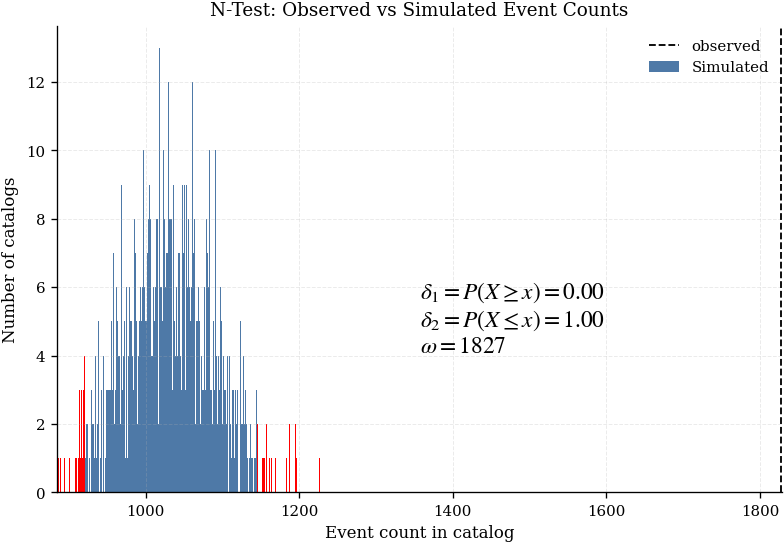

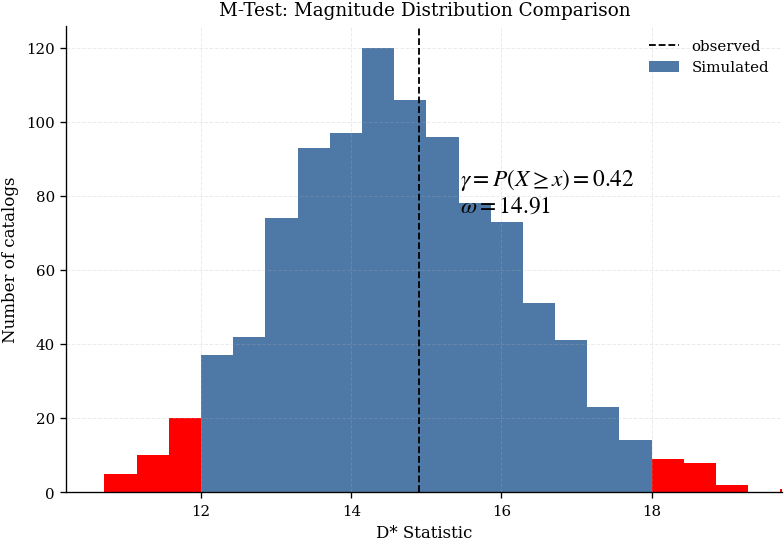

In [ ]:
forecast_counts = np.array([len(fc) for fc in all_forecasts], dtype=float)
observed_count = len(observed_seq)
# rmse = float(np.sqrt(np.mean((forecast_counts - observed_count) ** 2)))
# print(f'RMSE: {rmse:.6f}')

number_test_result = catalog_tests.run_number_test_result(
    event_counts=[len(fc) for fc in all_forecasts],
    obs_count=observed_count,
    min_mw=catalog_ds.metadata['mag_completeness'],
    obs_name='observed',
    sim_name='Simulated',
    plot=False,
 )
number_test_result.plot(plot_args={'figsize': (6.8, 4.8), 'tight_layout': False})
fig_n = style_current_figure(title='N-Test: Observed vs Simulated Event Counts')
save_pub_figure(fig_n, CHECKPOINT_DIR / 'n_test.pdf')

non_empty_forecasts = [fc for fc in all_forecasts if len(fc) > 0]
empty_forecast_count = len(all_forecasts) - len(non_empty_forecasts)
print('Empty forecasts:', empty_forecast_count)

if non_empty_forecasts:
    mag_max = [fc.mag.max().item() for fc in non_empty_forecasts]
    mag_min = [fc.mag.min().item() for fc in non_empty_forecasts]
    print('Forecast mag range (non-empty only):', (max(mag_max), min(mag_min)))
else:
    print('Forecast mag range: no non-empty forecasts')

if len(observed_seq) > 0:
    print('Observed mag range:', (observed_seq.mag.max().item(), observed_seq.mag.min().item()))
else:
    print('Observed mag range: observed sequence is empty')

config_dict = {
    'min_mw': catalog_ds.metadata['mag_completeness'],
    'max_mw': 5,
    'dmw': 0.01,
}

if non_empty_forecasts:
    # quick check distribution API on one non-empty forecast
    _ = catalog_tests.compute_magnitude_distribution(non_empty_forecasts[0].mag.cpu().numpy(), **config_dict)

get_counts = functools.partial(catalog_tests.compute_magnitude_distribution, **config_dict)
result_dict = catalog_tests.magnitude_test_from_counts(
    observed_catalog=observed_seq,
    forecast_catalogs=all_forecasts,
    get_counts=lambda cat: get_counts(np.asarray(cat.mag.cpu()))[1],
    verbose=False,
    debug=False,
 )

magnitude_test_result = catalog_tests.run_magnitude_test_result(
    result_dict=result_dict,
    obs_catalog_repr='obs',
    obs_name='observed',
    sim_name='Simulated',
    plot=False,
 )
try:
    magnitude_test_result.plot(plot_args={'figsize': (6.8, 4.8), 'tight_layout': False})
    fig_m = style_current_figure(title='M-Test: Magnitude Distribution Comparison')
    save_pub_figure(fig_m, CHECKPOINT_DIR / 'm_test.pdf')
except Exception as exc:
    print(f'Skipping M-test plot due to error: {exc}')

## 7) Sliding-Window Forecast Evaluation

In [ ]:
# Sliding-window settings
SLIDING_DURATION = 2
SLIDING_STEP = 2
SLIDING_QUANTILES = (2.5, 97.5)
RUN_SLIDING_WINDOW_FORECAST = True  # set to True to run the sliding window forecast, which can be time-consuming depending on settings
SLIDING_VIEW_MODE = 'zoomed'  # 'zoomed' | 'full' | 'auto'
UPDATER_CACHE_TAG = UPDATER_NAME if FORECAST_B_SAMPLING == 'updater' else 'model'
SLIDING_CACHE_FILENAME = f'sliding_window_cache_{FORECAST_B_SAMPLING}_{UPDATER_CACHE_TAG}.npz'
LOAD_SLIDING_CACHE = True  # reuse cached sliding forecasts when settings match
FORCE_RECOMPUTE_SLIDING = False  # set True only when the cache must be refreshed


In [ ]:
if hasattr(model, "predict_b"):
    model.predict_b = CKPT_PREDICT_B
if "sampling_model" in locals() and hasattr(sampling_model, "predict_b"):
    sampling_model.predict_b = CKPT_PREDICT_B
if not hasattr(model, "predict_b"):
    print('Current model has no predict_b flag (expected for ETAS-family models).')
print(f"Sampling uses checkpoint predict_b: {CKPT_PREDICT_B}")


Current model has no predict_b flag (expected for ETAS-family models).
Sampling uses checkpoint predict_b: False


NETAS sampling may be slow: batch_size=1000, past_events=152, estimated parent-history work=152000. Consider reducing `samples_per_batch` or forecast horizon.
NETAS sampling may be slow: batch_size=1000, past_events=280, estimated parent-history work=280000. Consider reducing `samples_per_batch` or forecast horizon.
NETAS sampling may be slow: batch_size=1000, past_events=506, estimated parent-history work=506000. Consider reducing `samples_per_batch` or forecast horizon.
NETAS sampling may be slow: batch_size=1000, past_events=740, estimated parent-history work=740000. Consider reducing `samples_per_batch` or forecast horizon.
NETAS sampling may be slow: batch_size=1000, past_events=753, estimated parent-history work=753000. Consider reducing `samples_per_batch` or forecast horizon.
NETAS sampling may be slow: batch_size=1000, past_events=753, estimated parent-history work=753000. Consider reducing `samples_per_batch` or forecast horizon.
NETAS sampling may be slow: batch_size=1000, p

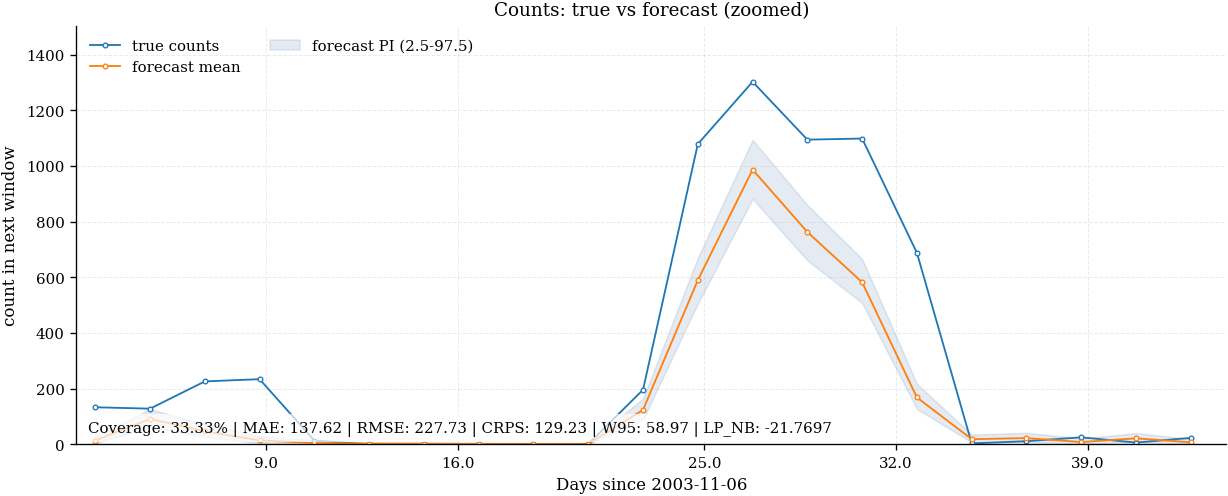

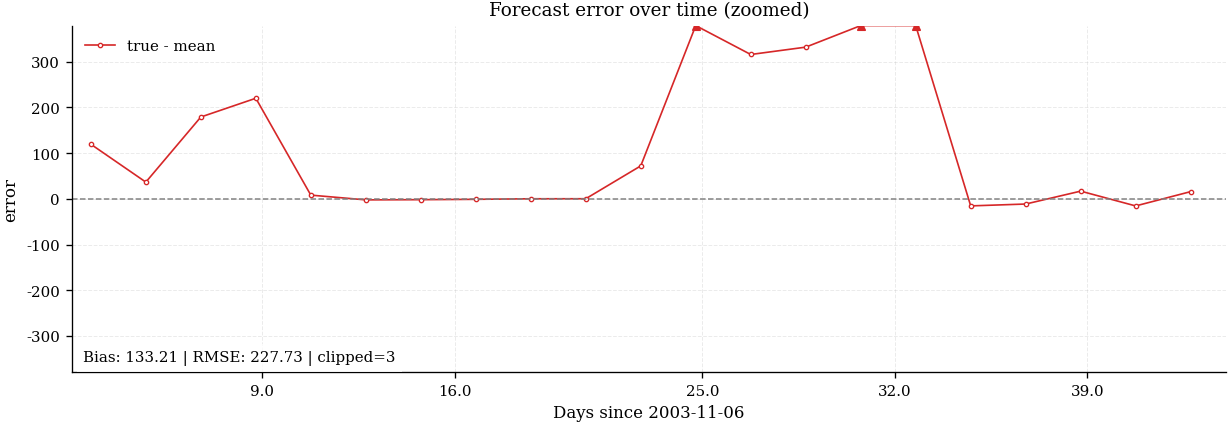

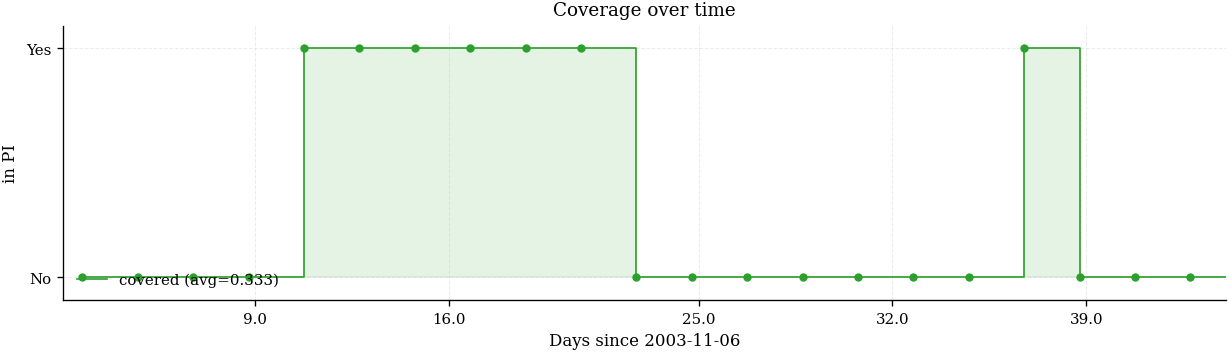

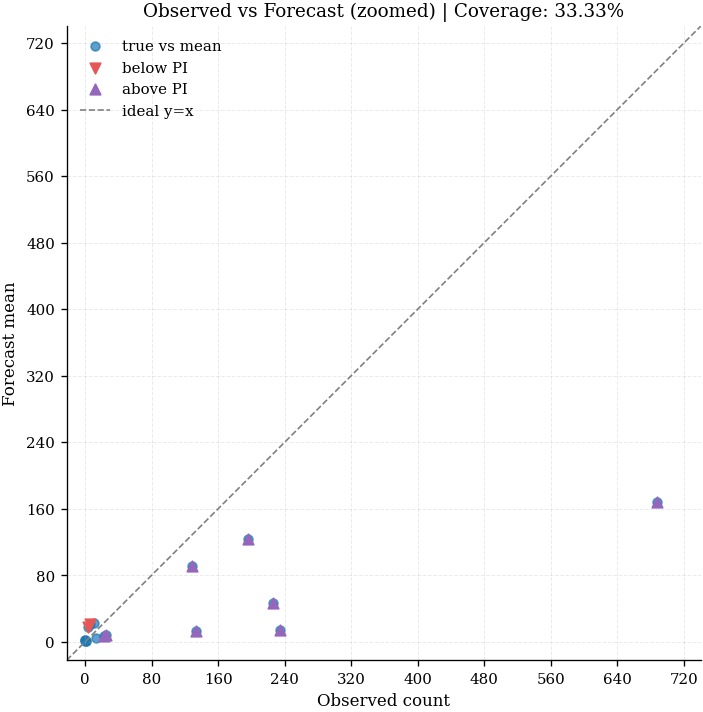

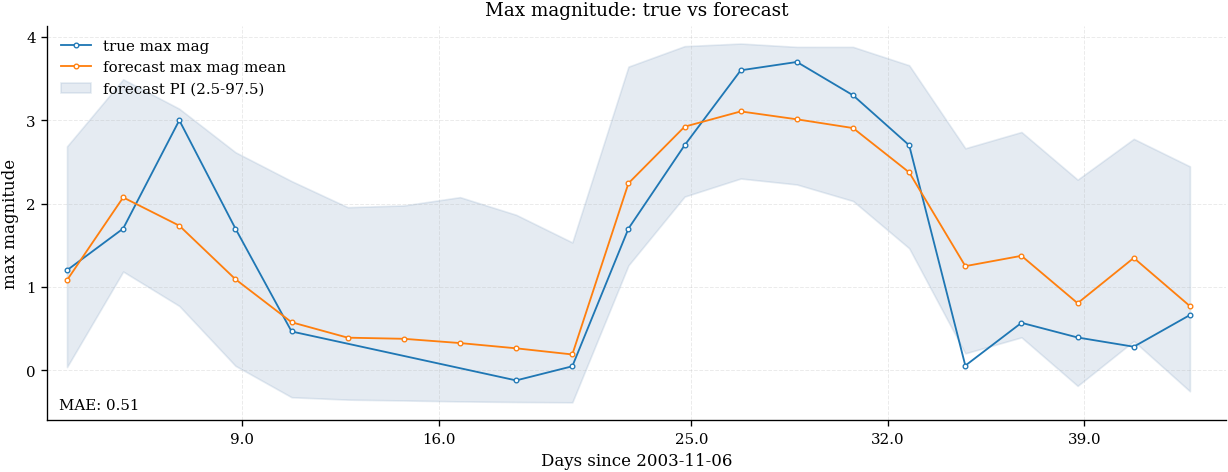

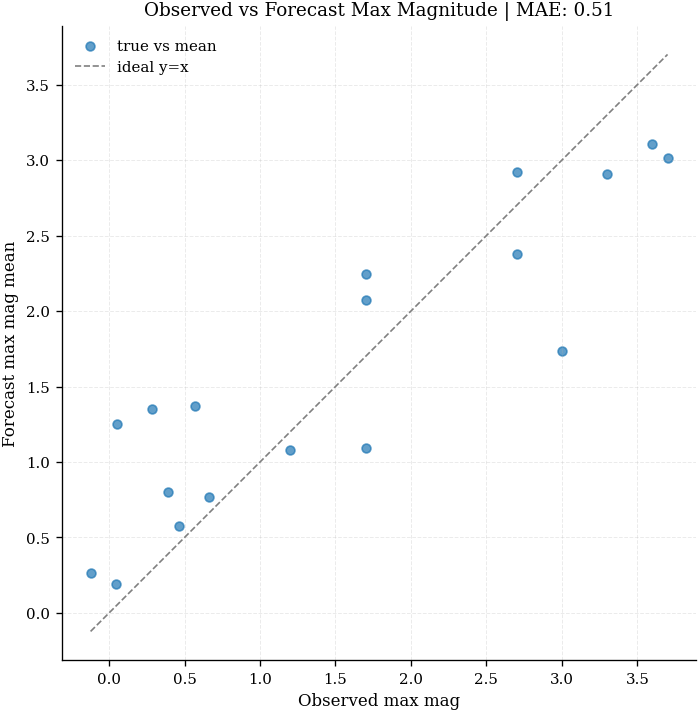

acceptance rate: 33.33%
MAE: 137.6157 | RMSE: 227.7337 | CRPS: 129.2316 | LP_NB: -21.7697 | W95: 58.9714
Sliding cache: computed_and_saved | /root/autodl-tmp/em_eqf/checkpoints/netas_20260610-213620/sliding_window_cache_model_model.npz


In [ ]:
PLOT_COLORS = {
    'true': '#1f77b4',
    'mean': '#ff7f0e',
    'pi': '#4c78a8',
    'err': '#d62728',
    'covered': '#2ca02c',
    'below': '#e45756',
    'above': '#9467bd',
}

if RUN_SLIDING_WINDOW_FORECAST:
    sliding_result = evaluate_sliding_window_forecast_plots(
        model=sampling_model,
        seq=seq,
        device=DEVICE,
        catalog_ds=catalog_ds,
        checkpoint_dir=CHECKPOINT_DIR,
        sliding_duration=SLIDING_DURATION,
        sliding_step=SLIDING_STEP,
        sliding_quantiles=SLIDING_QUANTILES,
        samples_per_batch=SAMPLES_PER_BATCH,
        predict_b=CKPT_PREDICT_B,
        bg_cache_seq=seq,
        sliding_view_mode=SLIDING_VIEW_MODE,
        load_sliding_cache=LOAD_SLIDING_CACHE,
        force_recompute_sliding=FORCE_RECOMPUTE_SLIDING,
        sliding_cache_filename=SLIDING_CACHE_FILENAME,
        plot_colors=PLOT_COLORS,
    )

    if sliding_result.get('status') == 'empty':
        print(sliding_result['message'])
    else:
        t_forecast_list = sliding_result['t_forecast_list']
        counts_list = sliding_result['counts_list']
        mag_max_mae =sliding_result['mag_max_mae']
        q_list = sliding_result['q_list']
        mean_list = sliding_result['mean_list']
        print(f"acceptance rate: {sliding_result['coverage']:.2%}")
        lp_nb = sliding_result.get('lp_nb')
        crps = sliding_result.get('crps')
        w95 = sliding_result.get('w95')
        lp_nb_display = 'N/A' if lp_nb is None or not np.isfinite(lp_nb) else f"{lp_nb:.4f}"
        crps_display = 'N/A' if crps is None or not np.isfinite(crps) else f"{crps:.4f}"
        print(
            f"MAE: {sliding_result['mae']:.4f} | RMSE: {sliding_result['rmse']:.4f} | CRPS: {crps_display} | LP_NB: {lp_nb_display} | W95: {w95:.4f}"
        )

    cache_path = sliding_result.get('sliding_cache_path')
    loaded_from_cache = sliding_result.get('sliding_loaded_from_cache')
    if cache_path is not None:
        cache_state = 'loaded' if bool(loaded_from_cache) else 'computed_and_saved'
        print(f"Sliding cache: {cache_state} | {cache_path}")

In [ ]:
sliding_window_eval_metrics = {
    'status': 'ok',
    'coverage': float(sliding_result['coverage']),
    'mae': float(sliding_result['mae']),
    'rmse': float(sliding_result['rmse']),
    'crps': None if crps is None or not np.isfinite(crps) else float(crps),
    'w95': float(sliding_result['w95']),
    'lp_nb': None if lp_nb is None or not np.isfinite(lp_nb) else float(lp_nb),
    'num_windows': int(len(sliding_result['t_forecast_list'])),
    'settings': {
        'duration': float(SLIDING_DURATION),
        'step': float(SLIDING_STEP),
        'quantiles': [float(SLIDING_QUANTILES[0]), float(SLIDING_QUANTILES[1])],
        'samples_per_batch': int(SAMPLES_PER_BATCH),
        'predict_b': bool(CKPT_PREDICT_B),
        'view_mode': str(SLIDING_VIEW_MODE),
        'cache_filename': str(SLIDING_CACHE_FILENAME),
        'load_sliding_cache': bool(LOAD_SLIDING_CACHE),
        'force_recompute_sliding': bool(FORCE_RECOMPUTE_SLIDING),
    },
    'sliding_cache_path': sliding_result.get('sliding_cache_path'),
    'sliding_loaded_from_cache': bool(sliding_result.get('sliding_loaded_from_cache')),
}

metrics_path = CHECKPOINT_DIR / 'sliding_window_eval_metrics.json'
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(sliding_window_eval_metrics, f, ensure_ascii=False, indent=2)

print(f"Sliding-window metrics saved into checkpoint: {metrics_path}")


Sliding-window metrics saved into checkpoint: /root/autodl-tmp/em_eqf/checkpoints/netas_20260610-213620/sliding_window_eval_metrics.json


In [ ]:
sliding_window_eval_metrics

{'status': 'ok',
 'coverage': 0.3333333333333333,
 'mae': 137.6157142857143,
 'rmse': 227.73368762009633,
 'crps': 129.23157238095237,
 'w95': 58.971428571428554,
 'lp_nb': -21.769652231055666,
 'num_windows': 21,
 'settings': {'duration': 2.0,
  'step': 2.0,
  'quantiles': [2.5, 97.5],
  'samples_per_batch': 1000,
  'predict_b': False,
  'view_mode': 'zoomed',
  'cache_filename': 'sliding_window_cache_model_model.npz',
  'load_sliding_cache': True,
  'force_recompute_sliding': False},
 'sliding_cache_path': '/root/autodl-tmp/em_eqf/checkpoints/netas_20260610-213620/sliding_window_cache_model_model.npz',
 'sliding_loaded_from_cache': False}

In [ ]:
import numpy as np

model.eval()
grid_device = getattr(model, 'device', DEVICE)
test_grid = torch.linspace(0, 1, 200, device=grid_device)

pred_dist = None
if hasattr(model, 'bg_model') and hasattr(model.bg_model, 'svgp'):
    with torch.no_grad():
        pred_dist = model.bg_model.svgp(test_grid.unsqueeze(-1))
elif hasattr(model, 'bg_model') and hasattr(model.bg_model, 'gp_model'):
    try:
        with torch.no_grad():
            pred_dist = model.bg_model.gp_model(test_grid.unsqueeze(-1))
    except Exception as exc:
        print(f'Skip latent GP plot: unable to query gp_model ({exc}).')
else:
    print("Skip latent GP plot: bg_model has no 'svgp' or 'gp_model' interface.")

if pred_dist is not None:
    mean = pred_dist.mean.detach().cpu().numpy()
    var = pred_dist.variance.detach().cpu().numpy()
    std = np.sqrt(var)

    latent_idx = 0
    x = test_grid.detach().cpu().numpy().reshape(-1)
    if mean.ndim == 2:
        y = mean[:, latent_idx]
        y_std = std[:, latent_idx]
    else:
        y = mean.reshape(-1)
        y_std = std.reshape(-1)

    fig, ax = plt.subplots(figsize=(8.8, 4.4))
    ax.plot(
        x,
        y,
        color='#1f77b4',
        linewidth=1.2,
        label=f'Latent Mean (dim={latent_idx})',
    )
    ax.fill_between(
        x,
        y - 2 * y_std,
        y + 2 * y_std,
        alpha=0.18,
        color='#4c78a8',
        label='+- 2 StdDev',
    )
    ax.set_xlabel('Normalized Time')
    ax.set_ylabel('Latent Value')
    ax.set_title('Latent Background Process Posterior')
    ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False)
    fig.tight_layout()
    save_pub_figure(fig, CHECKPOINT_DIR / 'latent_background_posterior.png')
    plt.show()


Skip latent GP plot: bg_model has no 'svgp' or 'gp_model' interface.


In [ ]:
batch.time_series_times

tensor([[0.0000e+00, 6.9444e-04, 1.3889e-03,  ..., 4.6747e+01, 4.6748e+01,
         4.6749e+01]], device='cuda:0')

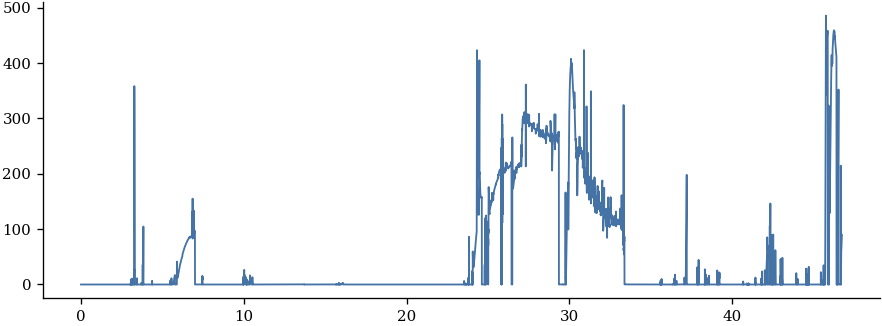

In [ ]:
if getattr(model, 'bg_model', None) is not None:
    f_intensity_trajectory = model.bg_model.intensity_trajectory(batch)
    fig, ax = plt.subplots(figsize=(9, 3.2))
    ax.plot(
        batch.time_series_times.squeeze().detach().cpu().numpy(),
        f_intensity_trajectory.squeeze().detach().cpu().numpy(),
        linewidth=1.1,
        color=diag_colors['bg'],
        label='background intensity',
    )

## 8) Synthetic Time-Series Probes for Background Response

Construct several typical input time-series patterns on the same time grid and compare how the background model responds.

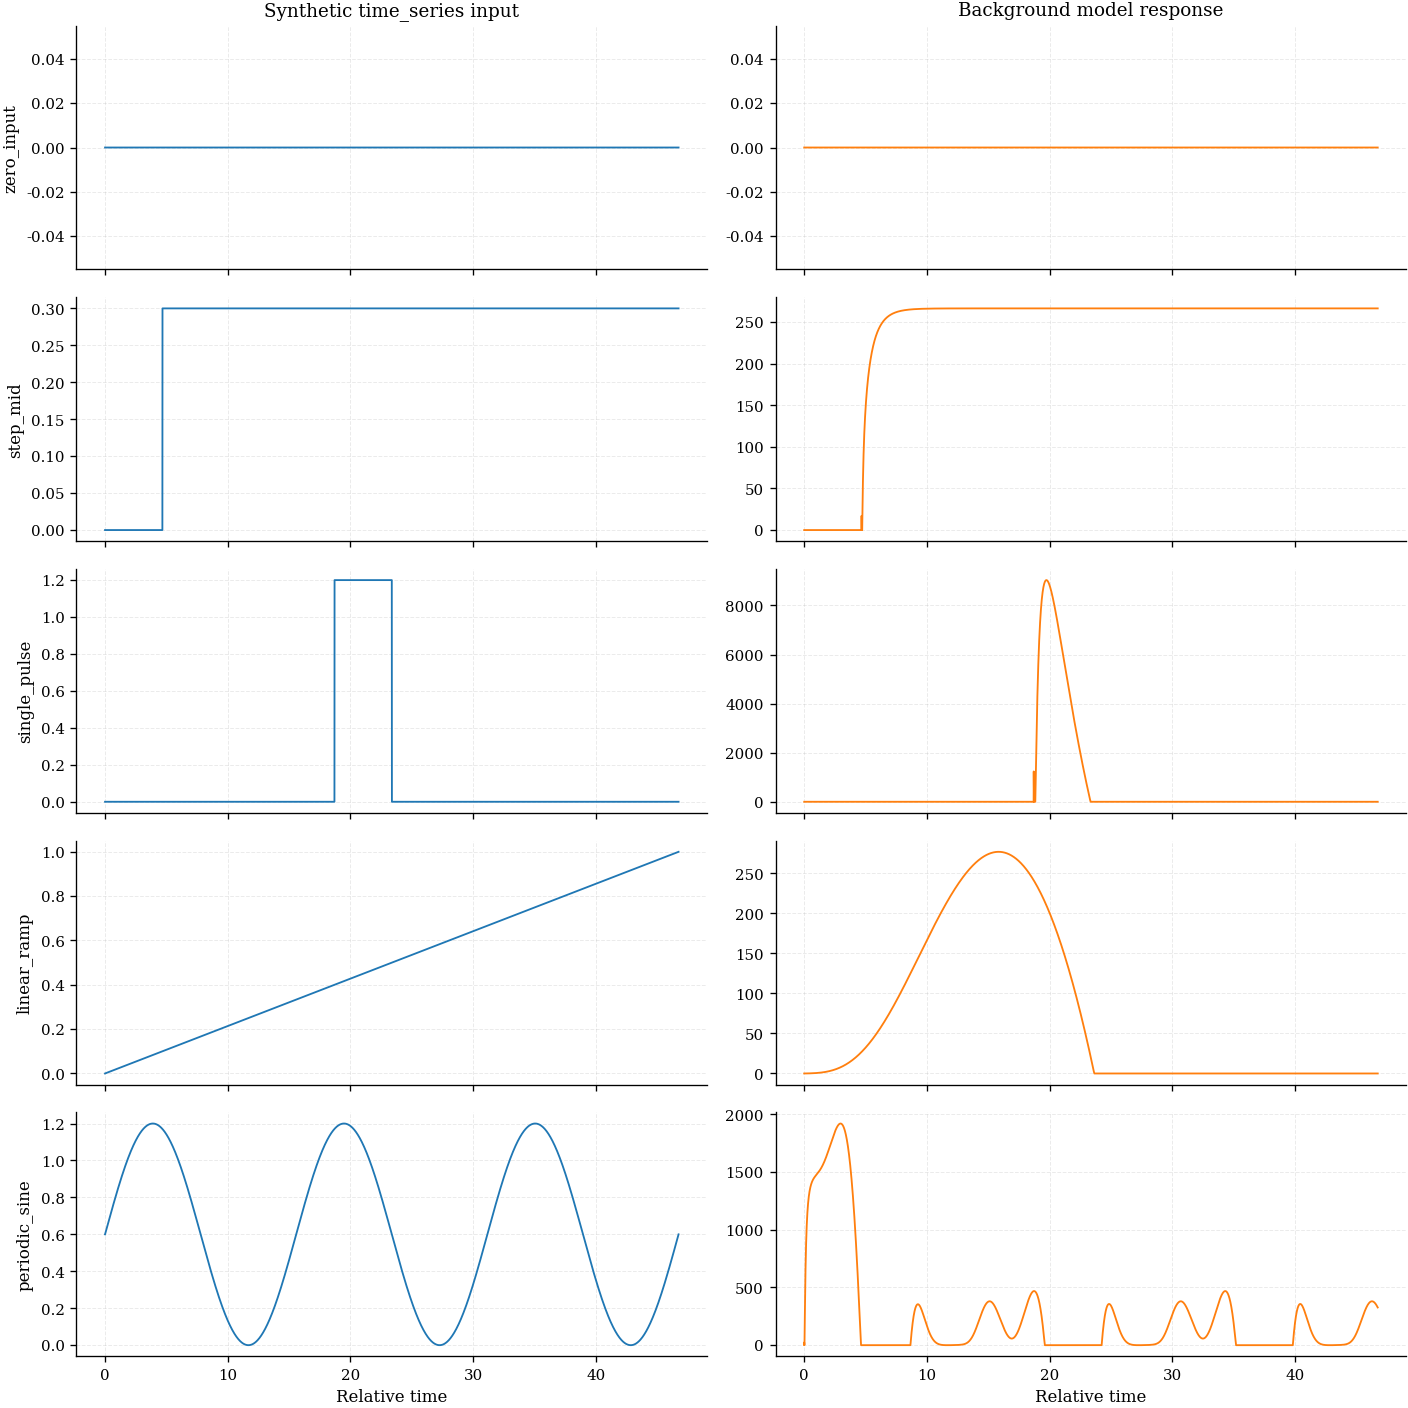

In [ ]:
if getattr(model, 'bg_model', None) is None:
    print('Skip synthetic probe diagnostics: model has no bg_model.')
else:
    probe_times = batch.time_series_times.reshape(-1).detach().to(DEVICE)
    t0 = float(probe_times.min().item())
    t1 = float(probe_times.max().item())
    span = max(t1 - t0, 1e-8)

    x = (probe_times - t0) / span

    probe_series = {
        'zero_input': torch.zeros_like(x),
        'step_mid': torch.where(x >= 0.1, torch.tensor(0.3, device=DEVICE), torch.tensor(0.0, device=DEVICE)),
        'single_pulse': torch.where((x >= 0.40) & (x <= 0.50), torch.tensor(1.2, device=DEVICE), torch.tensor(0.0, device=DEVICE)),
        'linear_ramp': x,
        'periodic_sine': 0.6 * (torch.sin(2 * torch.pi * 3 * x) + 1.0),
    }

    fig, axes = plt.subplots(len(probe_series), 2, figsize=(12, 2.4 * len(probe_series)), sharex=True)
    if len(probe_series) == 1:
        axes = np.array([axes])

    for row_idx, (name, ts_values) in enumerate(probe_series.items()):
        probe_batch = sequence_to_batch(seq, DEVICE)
        probe_batch.time_series_times = probe_times.unsqueeze(0)
        probe_batch.time_series = ts_values.unsqueeze(0).unsqueeze(-1)

        with torch.no_grad():
            bg_response = model.bg_model.intensity_trajectory(probe_batch).reshape(-1)

        t_np = probe_times.detach().cpu().numpy()
        ts_np = ts_values.detach().cpu().numpy()
        bg_np = bg_response.detach().cpu().numpy()

        ax_l, ax_r = axes[row_idx]
        ax_l.plot(t_np, ts_np, color='#1f77b4', linewidth=1.1)
        ax_l.set_ylabel(name)
        ax_l.grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
        ax_l.spines['top'].set_visible(False)
        ax_l.spines['right'].set_visible(False)

        ax_r.plot(t_np, bg_np, color='#ff7f0e', linewidth=1.1)
        ax_r.grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
        ax_r.spines['top'].set_visible(False)
        ax_r.spines['right'].set_visible(False)

    axes[0, 0].set_title('Synthetic time_series input')
    axes[0, 1].set_title('Background model response')
    axes[-1, 0].set_xlabel('Relative time')
    axes[-1, 1].set_xlabel('Relative time')

    fig.tight_layout()
    save_pub_figure(fig, CHECKPOINT_DIR / 'bg_response_synthetic_probes.png')
    plt.show()

## 9) Memory Effect Test: Keep vs Remove Previous Segment

Use the same second-segment input and compare background responses between:
- keep previous segment: first segment is a decaying signal;
- remove previous segment: first segment is replaced by zeros.

If responses differ on the second segment, the background model has path/history dependence.

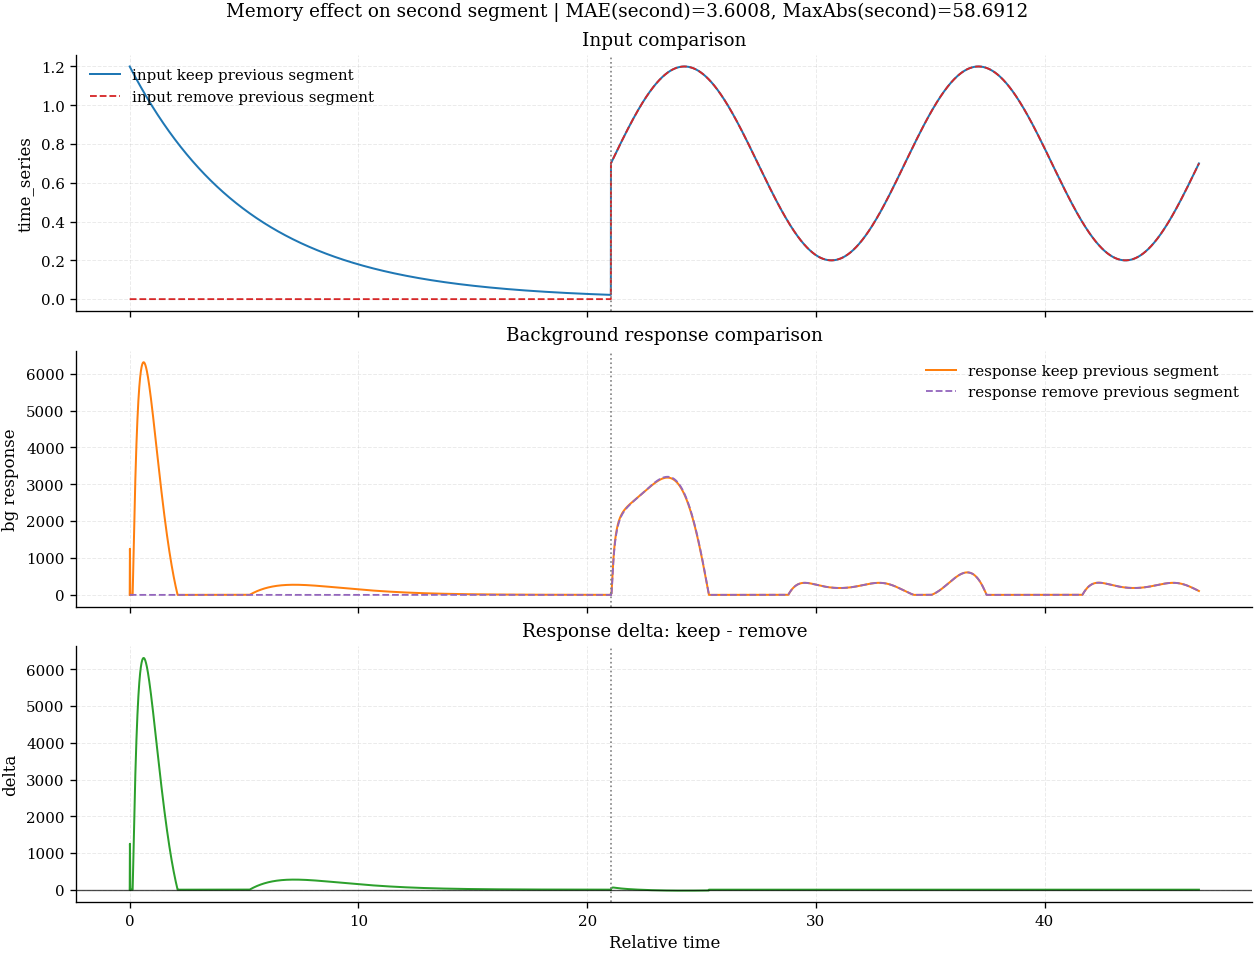

Second segment MAE (keep vs remove): 3.600842
Second segment MaxAbs diff: 58.691162
Interpretation: if both metrics are near 0, second-segment response is almost independent of previous segment.


In [ ]:
if getattr(model, 'bg_model', None) is None:
    print('Skip memory-effect test: model has no bg_model.')
else:
    probe_times = batch.time_series_times.reshape(-1).detach().to(DEVICE)
    t0 = float(probe_times.min().item())
    t1 = float(probe_times.max().item())
    span = max(t1 - t0, 1e-8)
    x = (probe_times - t0) / span

    split_ratio = 0.45
    mask_first = x < split_ratio
    mask_second = ~mask_first

    # First segment: high-to-low exponential decay to near zero.
    tau = max(split_ratio * 0.25, 1e-4)
    first_decay = 1.2 * torch.exp(-x / tau)
    first_decay = torch.where(mask_first, first_decay, torch.tensor(0.0, device=DEVICE))

    # Second segment: fixed input used by both experiments.
    x2 = torch.clamp((x - split_ratio) / max(1.0 - split_ratio, 1e-8), min=0.0)
    second_segment = torch.where(mask_second, 0.7 + 0.5 * torch.sin(2 * torch.pi * 2 * x2), torch.tensor(0.0, device=DEVICE))

    ts_keep = first_decay + second_segment
    ts_remove = torch.where(mask_second, second_segment, torch.tensor(0.0, device=DEVICE))

    def run_bg_response(ts_values: torch.Tensor) -> torch.Tensor:
        probe_batch = sequence_to_batch(seq, DEVICE)
        probe_batch.time_series_times = probe_times.unsqueeze(0)
        probe_batch.time_series = ts_values.unsqueeze(0).unsqueeze(-1)
        with torch.no_grad():
            return model.bg_model.intensity_trajectory(probe_batch).reshape(-1)

    resp_keep = run_bg_response(ts_keep)
    resp_remove = run_bg_response(ts_remove)

    # Compare only on second segment.
    resp_keep_2 = resp_keep[mask_second]
    resp_remove_2 = resp_remove[mask_second]
    diff_2 = resp_keep_2 - resp_remove_2
    mae_2 = torch.mean(torch.abs(diff_2)).item()
    max_abs_2 = torch.max(torch.abs(diff_2)).item()

    t_np = probe_times.detach().cpu().numpy()
    ts_keep_np = ts_keep.detach().cpu().numpy()
    ts_remove_np = ts_remove.detach().cpu().numpy()
    resp_keep_np = resp_keep.detach().cpu().numpy()
    resp_remove_np = resp_remove.detach().cpu().numpy()

    fig, axes = plt.subplots(3, 1, figsize=(10.5, 8.0), sharex=True, constrained_layout=True)

    axes[0].plot(t_np, ts_keep_np, color='#1f77b4', linewidth=1.2, label='input keep previous segment')
    axes[0].plot(t_np, ts_remove_np, color='#d62728', linewidth=1.1, linestyle='--', label='input remove previous segment')
    axes[0].set_ylabel('time_series')
    axes[0].set_title('Input comparison')
    axes[0].grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
    axes[0].legend(frameon=False)

    axes[1].plot(t_np, resp_keep_np, color='#ff7f0e', linewidth=1.2, label='response keep previous segment')
    axes[1].plot(t_np, resp_remove_np, color='#9467bd', linewidth=1.1, linestyle='--', label='response remove previous segment')
    axes[1].set_ylabel('bg response')
    axes[1].set_title('Background response comparison')
    axes[1].grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
    axes[1].legend(frameon=False)

    diff_full = (resp_keep - resp_remove).detach().cpu().numpy()
    axes[2].plot(t_np, diff_full, color='#2ca02c', linewidth=1.2)
    axes[2].axhline(0.0, color='black', linewidth=0.8, alpha=0.7)
    axes[2].set_ylabel('delta')
    axes[2].set_xlabel('Relative time')
    axes[2].set_title('Response delta: keep - remove')
    axes[2].grid(True, alpha=0.25, linestyle='--', linewidth=0.6)

    split_time = t0 + split_ratio * span
    for ax in axes:
        ax.axvline(split_time, color='gray', linewidth=1.0, linestyle=':')

    fig.suptitle(
        f'Memory effect on second segment | MAE(second)={mae_2:.4f}, MaxAbs(second)={max_abs_2:.4f}',
        fontsize=11,
    )
    save_pub_figure(fig, CHECKPOINT_DIR / 'bg_response_memory_effect_keep_vs_remove.png')
    plt.show()

    print(f'Second segment MAE (keep vs remove): {mae_2:.6f}')
    print(f'Second segment MaxAbs diff: {max_abs_2:.6f}')
    print('Interpretation: if both metrics are near 0, second-segment response is almost independent of previous segment.')